In [62]:
# MODULO 2 — TEMA 2
# Ejercicio Integrador
# Parte 1: Estadísticas descriptivas

import pandas as pd
import numpy as np
# 1. Cargar base

df = pd.read_parquet('cartera_q1_2026_final_M2.parquet')
print(df.head())

# 2. Filtrar ramos
ramos_interes = ['ACCIDENTES PERSONALES','GASTOS MEDICOS']

df_ramos = (df[df['ramo'].isin(ramos_interes)].copy())
print(df_ramos['ramo'].value_counts())

# 3. Estadísticas descriptivas

resumen = (df_ramos.groupby('ramo').agg(Num_Polizas = ('id_poliza','nunique'),
Prima_Total = ('prima_total','sum'),
Prima_Promedio = ('prima_total','mean'),Num_Siniestros = ('n_siniestros','sum'),
Frecuencia_Promedio = ('n_siniestros','mean'),
Siniestro_Total = ('monto_pagado','sum'),
Siniestro_Promedio = ('monto_pagado','mean')).round(2))

# 4. Loss Ratio

resumen['Loss_Ratio'] = (resumen['Siniestro_Total'] / resumen['Prima_Total']).round(3)

# 5. Resultados

print('\n--- Estadísticas descriptivas ---')
print(resumen)


    id_poliza     num_poliza    nombre apellido_paterno apellido_materno  \
0  POL-000001  Vid-21-000001  Gabriela           Moreno             Vega   
1  POL-000002  Aut-19-000002   Valeria           Torres         Castillo   
2  POL-000003  GMM-22-000003  Fernanda            Ramos            Silva   
3  POL-000004  Vid-19-000004    Silvia          Mendoza        Gutierrez   
4  POL-000005  Vid-20-000005   Antonio            Ramos         Castillo   

             rfc  edad sexo estado_civil      ocupacion  ... comision_est  \
0  MOGV020429CG6    24    F  Union libre  Independiente  ...   5892.41952   
1  TOVC020815IA8    23    F       Casado       Contador  ...    882.44100   
2  RAFS941018BC1    31    M  Union libre      Ingeniero  ...   1995.45984   
3  MESG860204IH8    40    M      Soltero     Arquitecto  ...  14002.67088   
4  RAAC960722ME2    29    F      Soltero  Independiente  ...   6545.88000   

  nivel_riesgo anio_emision mes_emision trimestre  segmento_prima_fijo  \
0     

C:\Users\angel\AppData\Local\Temp\ipykernel_18616\4140872694.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen = (df_ramos.groupby('ramo').agg(Num_Polizas = ('id_poliza','nunique'),


Conclusión:

Las estadísticas descriptivas permitieron comparar
el comportamiento de los ramos de Accidentes Personales
y Gastos Médicos.

Se observó diferencia tanto en frecuencia como en severidad
de siniestros, lo que impacta directamente en la prima
y en el loss ratio de cada ramo.

La información también muestra que existen pólizas
con distintos niveles de riesgo y primas muy variables,
por lo que será importante aplicar transformaciones
y detección de outliers en las siguientes partes
del análisis.

En general, esta primera exploración ayuda a entender
la estructura de la cartera y detectar posibles riesgos
atípicos antes de construir modelos predictivos.

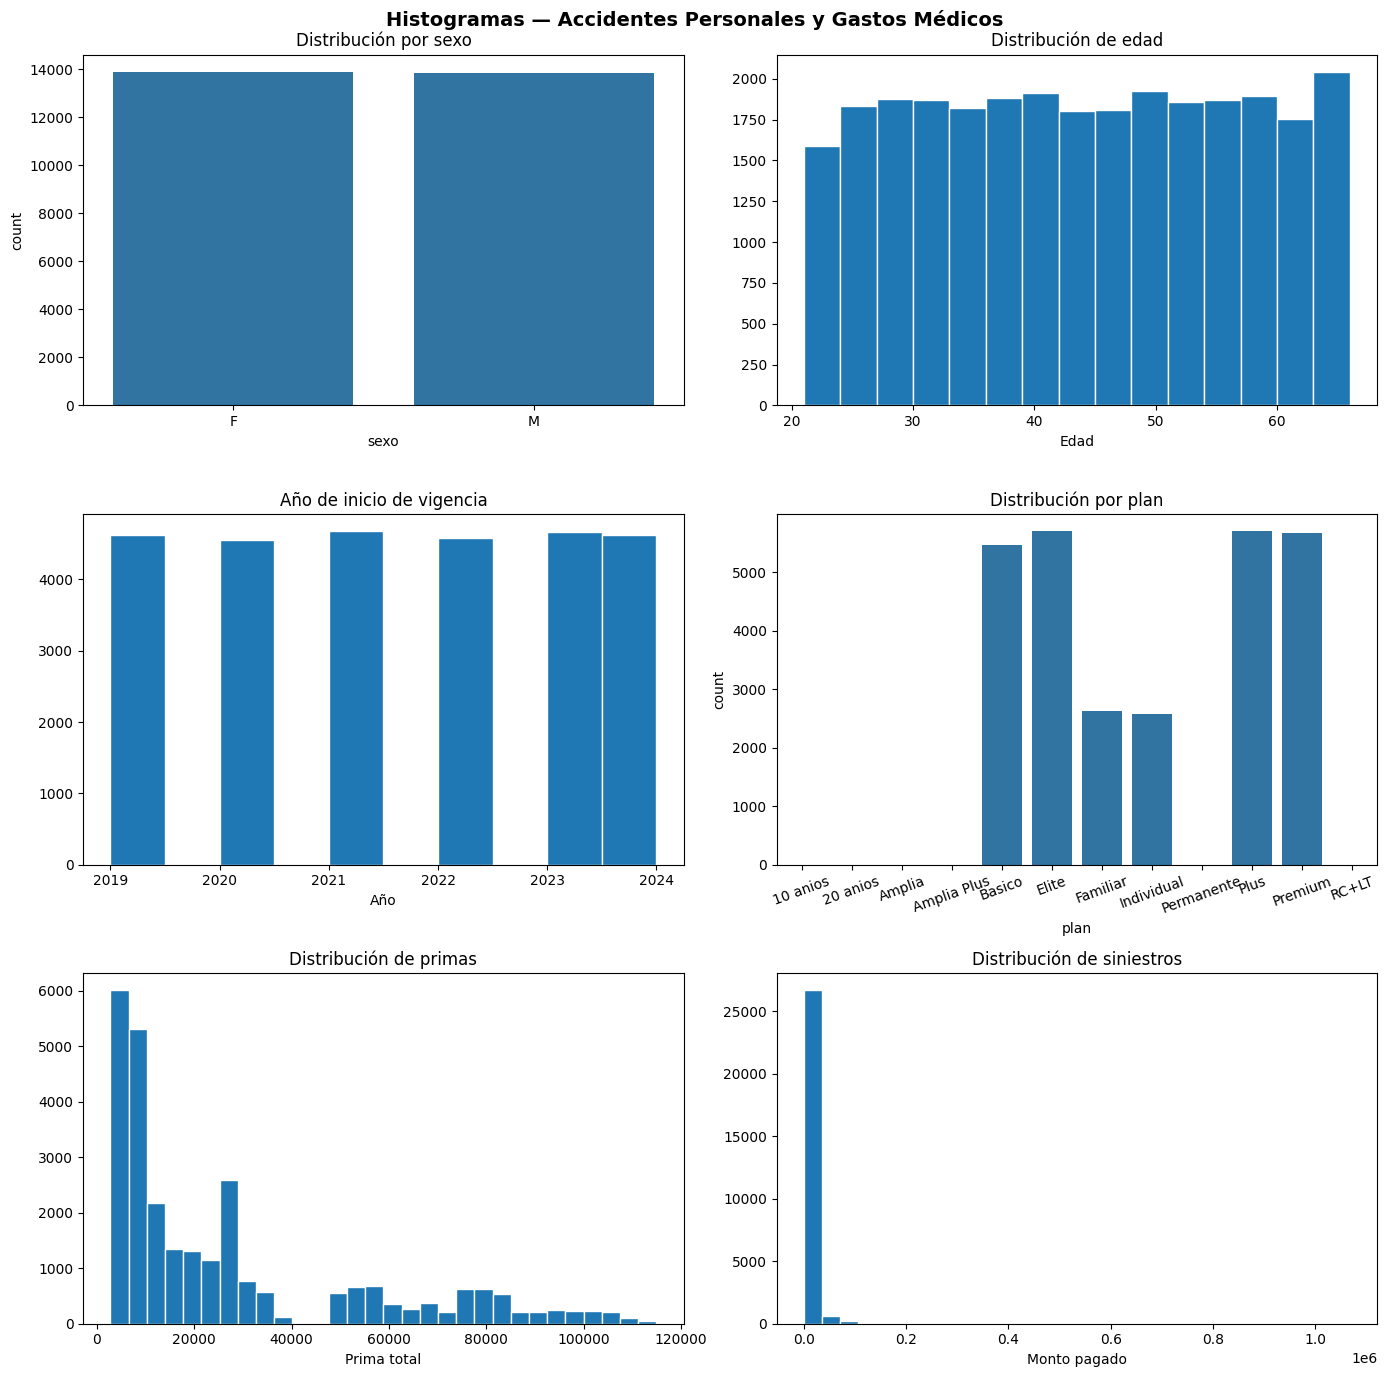

In [63]:
# 2. Histogramas y distribuciones
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar ramos

ramos_interes = ['Accidentes Personales','GMM']

df_ramos = (df[df['ramo'].isin(ramos_interes)].copy())

# Histogramas

fig, ax = plt.subplots(3, 2, figsize=(14, 14))

# Sexo
sns.countplot(data=df_ramos,x='sexo',ax=ax[0,0])
ax[0,0].set_title('Distribución por sexo')

# Edad

ax[0,1].hist(df_ramos['edad'],bins=15,edgecolor='white')

ax[0,1].set_title('Distribución de edad')
ax[0,1].set_xlabel('Edad')

# Año inicio vigencia

ax[1,0].hist(df_ramos['anio_poliza'],bins=10,edgecolor='white')

ax[1,0].set_title('Año de inicio de vigencia')
ax[1,0].set_xlabel('Año')

# Plan

sns.countplot(data=df_ramos,x='plan',ax=ax[1,1])

ax[1,1].set_title('Distribución por plan')
ax[1,1].tick_params(axis='x', rotation=20)

# Prima total

ax[2,0].hist(df_ramos['prima_total'],bins=30,edgecolor='white')

ax[2,0].set_title('Distribución de primas')
ax[2,0].set_xlabel('Prima total')

# Siniestros

ax[2,1].hist(df_ramos['monto_pagado'],bins=30,edgecolor='white')

ax[2,1].set_title('Distribución de siniestros')
ax[2,1].set_xlabel('Monto pagado')

plt.suptitle('Histogramas — Accidentes Personales y Gastos Médicos',fontsize=14,fontweight='bold')

plt.tight_layout()
plt.show()


Conclusión:

La distribución por sexo se observa bastante balanceada,
por lo que no parece existir una diferencia importante
en cantidad de asegurados entre hombres y mujeres.

La edad tiene una distribución relativamente uniforme,
aunque hay mayor concentración en edades adultas,
que suelen representar la mayor parte de la cartera.

Los años de inicio de vigencia muestran una cartera
estable entre 2019 y 2024, sin cambios extremos
en emisión de pólizas.

En la variable plan se observa que algunos productos,
como Básico, Elite y Premium, concentran gran parte
de las pólizas, mientras que otros tienen poca participación.

Las primas presentan una fuerte asimetría positiva:
la mayoría de las pólizas tienen primas bajas o medias,
pero existen algunas pólizas con primas muy altas.

La distribución de siniestros también muestra una cola
derecha muy pesada y presencia de valores extremos,
algo muy común en seguros debido a eventos severos
de alto costo.

En general, las variables monetarias no siguen
una distribución normal, por lo que será recomendable
usar transformaciones como log o arcsinh y métodos
de detección de outliers para futuros modelos predictivos.

In [64]:
# Filtrar correctamente
ramos_interes = ['Accidentes Personales','GMM']

df_ramos = (df.loc[df['ramo'].isin(ramos_interes)].copy())

# Verificar

print(df_ramos['ramo'].value_counts())

ramo
GMM                      22531
Accidentes Personales     5207
Autos                        0
Vida                         0
Name: count, dtype: int64


In [65]:
# 3. Codificación de variables
# Copia de trabajo

df_modelo = df_ramos.copy()

# 1. Label Encoding

# Sexo:
# Variable binaria, por eso se puede codificar
# directamente con 0 y 1.

df_modelo['sexo_cod'] = (df_modelo['sexo'].map({'F': 0,'M': 1}))

# Nivel de riesgo

# Tiene orden natural:
# BAJO < MEDIO < ALTO

df_modelo['riesgo_cod'] = (df_modelo['nivel_riesgo'].map({'BAJO': 1,'MEDIO': 2,'ALTO': 3}))

# 2. One Hot Encoding

# Para variables categóricas nominales
# sin orden natural.

variables_dummies = ['estado_civil','plan','canal_venta','region']

df_modelo = pd.get_dummies(df_modelo,columns=variables_dummies,drop_first=True)

# Resultado

print(df_modelo.head())

print('\nNúmero de columnas:')
print(df_modelo.shape[1])

     id_poliza     num_poliza    nombre apellido_paterno apellido_materno  \
2   POL-000003  GMM-22-000003  Fernanda            Ramos            Silva   
6   POL-000007  GMM-23-000007     Mario            Reyes         Castillo   
7   POL-000008  GMM-19-000008    Carlos           Rivera          Sanchez   
8   POL-000009  GMM-24-000009      Jose            Nunez            Reyes   
10  POL-000011  GMM-23-000011    Daniel            Ortiz         Martinez   

              rfc  edad sexo   ocupacion ramo  ... region_Guanajuato  \
2   RAFS941018BC1    31    M   Ingeniero  GMM  ...             False   
6   REMC680423LH5    58    M    Jubilado  GMM  ...             False   
7   RICS710805YY4    54    M    Director  GMM  ...             False   
8   NUJR930612XL7    32    M  Empresario  GMM  ...             False   
10  ORDM850718BP5    40    F    Analista  GMM  ...             False   

   region_Jalisco region_Michoacan  region_Nuevo Leon region_Puebla  \
2           False            Fals

Se codificaron las variables categóricas necesarias
para que puedan utilizarse en modelos predictivos.

Para sexo se aplicó Label Encoding porque es una variable
binaria y la codificación 0/1 es suficiente.

En nivel de riesgo también se utilizó Label Encoding
porque existe un orden natural entre BAJO, MEDIO y ALTO.

Para variables como plan, estado civil, región
y canal de venta se aplicó One Hot Encoding,
ya que no tienen un orden jerárquico y cada categoría
debe representarse de manera independiente.

La codificación permite transformar variables cualitativas
en variables numéricas que pueden ser utilizadas
por modelos estadísticos y de machine learning.

In [66]:
# Filtrar correctamente
ramos_interes = ['Accidentes Personales','GMM']

df_ramos = (df.loc[df['ramo'].isin(ramos_interes)].copy())

# Verificar
print(df_ramos['ramo'].value_counts())

ramo
GMM                      22531
Accidentes Personales     5207
Autos                        0
Vida                         0
Name: count, dtype: int64



--- Estadísticas comparativas ---
       Original Prima  Standard Prima  MinMax Prima  Robust Prima  \
count       27738.000       27738.000     27738.000     27738.000   
mean        27255.137           0.000         0.218         0.459   
std         27780.168           1.000         0.248         1.044   
min          2784.000          -0.881         0.000        -0.461   
25%          6960.000          -0.731         0.037        -0.304   
50%         15056.800          -0.439         0.109         0.000   
75%         33558.800           0.227         0.274         0.696   
max        114931.870           3.156         1.000         3.755   

       Original Siniestro  Standard Siniestro  MinMax Siniestro  \
count           27738.000           27738.000         27738.000   
mean             4298.208              -0.000             0.004   
std             21669.772               1.000             0.020   
min                 0.000              -0.198             0.000   
25%     

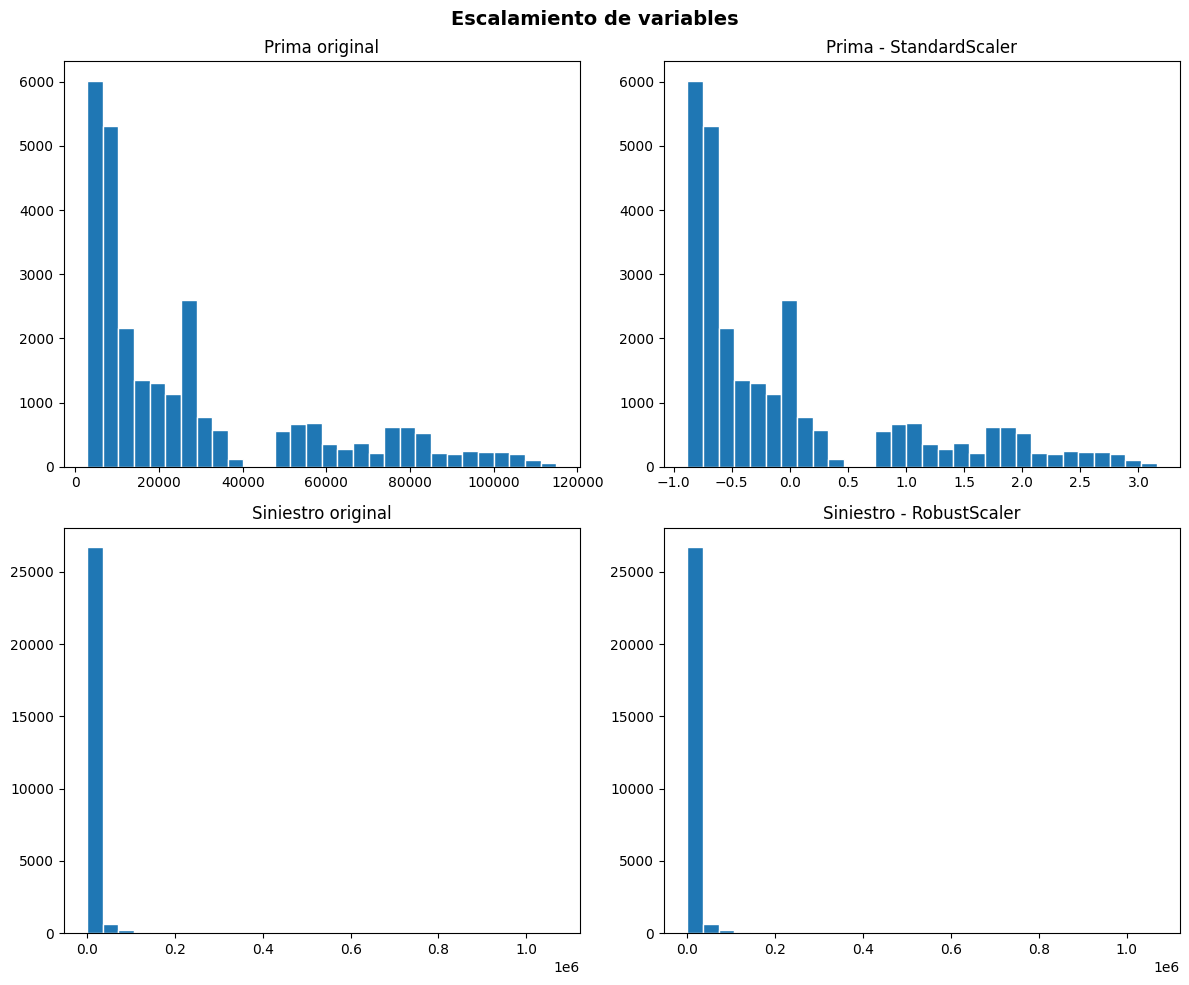

In [67]:
# 4. Escalamiento de primas y siniestros

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler)

# Variables numéricas

variables = ['prima_total','monto_pagado']

# Copia de trabajo

df_scaling = df_ramos[variables].copy()

# Escaladores

# 1. StandardScaler
scaler_std = StandardScaler()

df_std = pd.DataFrame(scaler_std.fit_transform(df_scaling),columns=['prima_std','siniestro_std'])

# 2. MinMaxScaler
scaler_mm = MinMaxScaler()

df_mm = pd.DataFrame(scaler_mm.fit_transform(df_scaling),columns=['prima_minmax','siniestro_minmax'])

# 3. RobustScaler
scaler_rb = RobustScaler()

df_rb = pd.DataFrame(scaler_rb.fit_transform(df_scaling),columns=['prima_robust','siniestro_robust'])

# Estadísticas comparativas

tabla_comp = pd.DataFrame({'Original Prima': df_scaling['prima_total'].describe(),
'Standard Prima': df_std['prima_std'].describe(),
'MinMax Prima': df_mm['prima_minmax'].describe(),
'Robust Prima': df_rb['prima_robust'].describe(),
'Original Siniestro': df_scaling['monto_pagado'].describe(),
'Standard Siniestro': df_std['siniestro_std'].describe(),
'MinMax Siniestro': df_mm['siniestro_minmax'].describe(),
'Robust Siniestro': df_rb['siniestro_robust'].describe()}).round(3)

print('\n--- Estadísticas comparativas ---')
print(tabla_comp)

# Visualización
fig, ax = plt.subplots(2, 2, figsize=(12,10))

# Prima original

ax[0,0].hist(df_scaling['prima_total'],bins=30,edgecolor='white')

ax[0,0].set_title('Prima original')

# Prima estandarizada

ax[0,1].hist(df_std['prima_std'],bins=30,edgecolor='white')

ax[0,1].set_title('Prima - StandardScaler')

# Siniestro original

ax[1,0].hist(df_scaling['monto_pagado'],bins=30,edgecolor='white')

ax[1,0].set_title('Siniestro original')

# Siniestro robust

ax[1,1].hist(df_rb['siniestro_robust'],bins=30,edgecolor='white')

ax[1,1].set_title('Siniestro - RobustScaler')

plt.suptitle('Escalamiento de variables',fontsize=14,fontweight='bold')

plt.tight_layout()
plt.show()



--- Estadísticas Prima ---
         Original  StandardScaler  MinMaxScaler  RobustScaler
count   27738.000       27738.000     27738.000     27738.000
mean    27255.137           0.000         0.218         0.459
std     27780.168           1.000         0.248         1.044
min      2784.000          -0.881         0.000        -0.461
25%      6960.000          -0.731         0.037        -0.304
50%     15056.800          -0.439         0.109         0.000
75%     33558.800           0.227         0.274         0.696
max    114931.870           3.156         1.000         3.755

--- Estadísticas Severidad (>0) ---
          Original  StandardScaler  MinMaxScaler  RobustScaler
count     3436.000        3436.000      3436.000      3436.000
mean     34698.394           0.000         0.032         0.471
std      52312.717           1.000         0.049         1.591
min         42.600          -0.663         0.000        -0.583
25%       8127.822          -0.508         0.008        -0.337

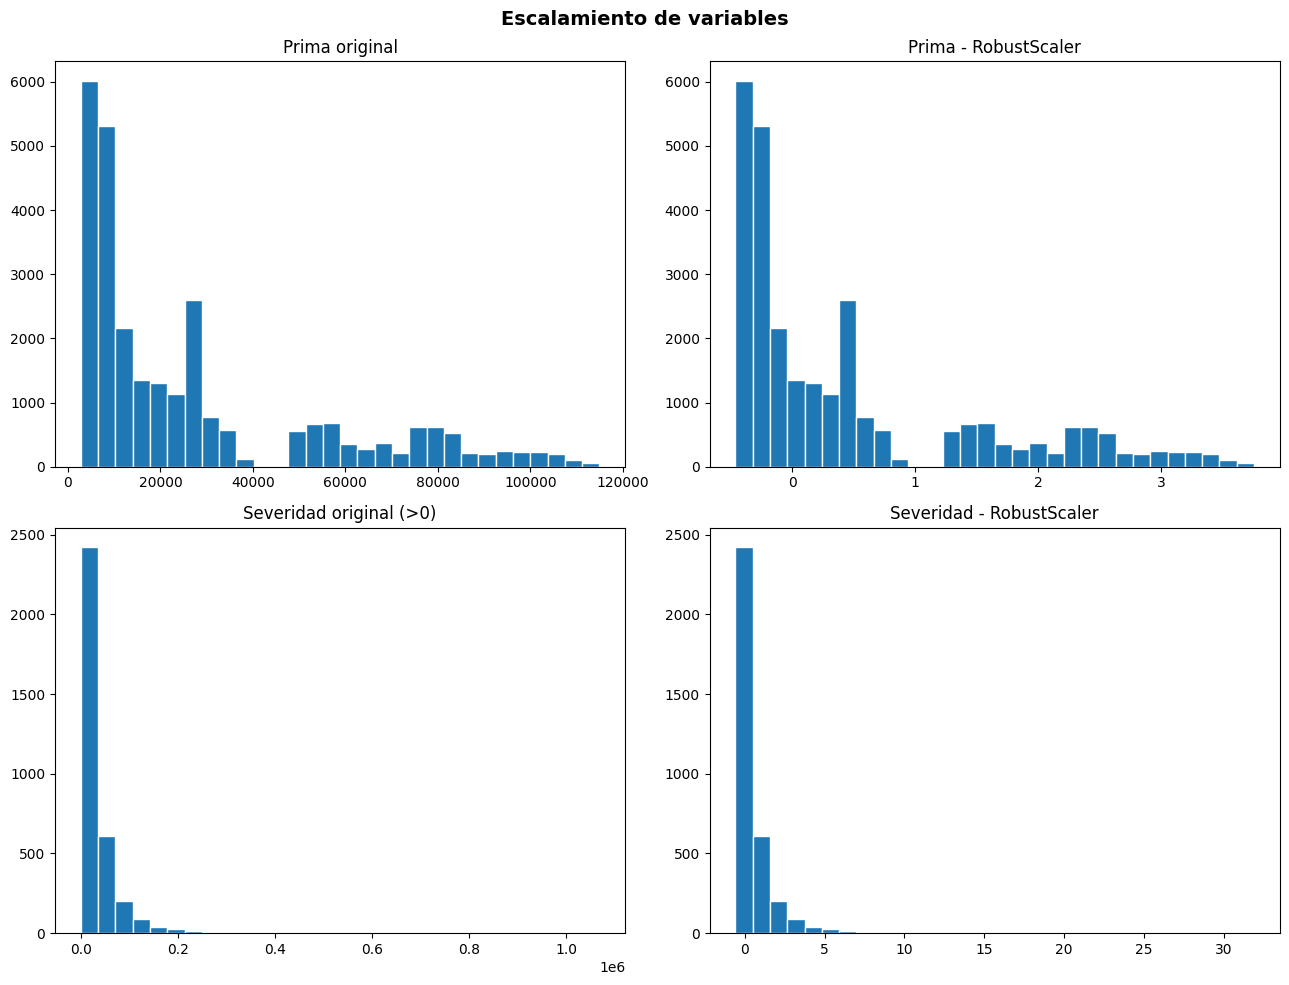

In [68]:
# 4. Escalamiento de primas y severidad
# SOLO severidades mayores a 0

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler)

# Variables

# Prima:
# se usa completa porque siempre existe.
prima = (df_ramos['prima_total'].copy())

# Severidad:
# solo pólizas con siniestro > 0

sev = (df_ramos[df_ramos['monto_pagado'] > 0]['monto_pagado'].copy())

# DataFrames

df_prima = pd.DataFrame({'prima_total': prima})

df_sev = pd.DataFrame({'monto_pagado': sev})

# 1. StandardScaler

scaler_std = StandardScaler()

prima_std = scaler_std.fit_transform(df_prima)

sev_std = scaler_std.fit_transform(df_sev)

# 2. MinMaxScaler

scaler_mm = MinMaxScaler()

prima_mm = scaler_mm.fit_transform(df_prima)

sev_mm = scaler_mm.fit_transform(df_sev)

# 3. RobustScaler

scaler_rb = RobustScaler()

prima_rb = scaler_rb.fit_transform(df_prima)

sev_rb = scaler_rb.fit_transform(df_sev)

# Estadísticas comparativas

tabla_prima = pd.DataFrame({
    'Original':prima.describe(),
    'StandardScaler':pd.Series(prima_std.flatten()).describe(),
    'MinMaxScaler':pd.Series(prima_mm.flatten()).describe(),
    'RobustScaler':pd.Series(prima_rb.flatten()).describe()}).round(3)

tabla_sev = pd.DataFrame({
    'Original':sev.describe(),
    'StandardScaler':pd.Series(sev_std.flatten()).describe(),
    'MinMaxScaler':pd.Series(sev_mm.flatten()).describe(),
    'RobustScaler':pd.Series(sev_rb.flatten()).describe()}).round(3)

print('\n--- Estadísticas Prima ---')
print(tabla_prima)

print('\n--- Estadísticas Severidad (>0) ---')
print(tabla_sev)

# Histogramas

fig, ax = plt.subplots(2, 2, figsize=(13,10))

# Prima original

ax[0,0].hist(prima,bins=30,edgecolor='white')

ax[0,0].set_title('Prima original')

# Prima RobustScaler

ax[0,1].hist(prima_rb,bins=30,edgecolor='white')

ax[0,1].set_title('Prima - RobustScaler')

# Severidad original
ax[1,0].hist(sev,bins=30,edgecolor='white')

ax[1,0].set_title('Severidad original (>0)')

# Severidad RobustScaler

ax[1,1].hist(sev_rb,bins=30,edgecolor='white')

ax[1,1].set_title('Severidad - RobustScaler')

plt.suptitle('Escalamiento de variables',fontsize=14,fontweight='bold')

plt.tight_layout()
plt.show()

# Conclusión


#Para la severidad se trabajó únicamente
#con montos mayores a cero, ya que las pólizas
#sin siniestro pertenecen al análisis de frecuencia.

#Las primas y severidades presentan asimetría positiva
#y presencia de valores extremos.

#StandardScaler centró las variables alrededor
#de cero y ajustó la desviación estándar,
#aunque sigue siendo sensible a outliers.

#MinMaxScaler comprimió los datos entre 0 y 1,
#pero los valores extremos continúan influyendo
#en la distribución.

#RobustScaler fue el método más estable,
#porque utiliza mediana e IQR, reduciendo
#el impacto de valores atípicos.

#En variables actuariales con colas pesadas,
#como primas y severidades, RobustScaler
#resulta más adecuado para modelos predictivos.



Las variables de primas y siniestros presentan
alta dispersión y valores extremos importantes,
especialmente en siniestros.

En primas, aunque existen valores altos,
la distribución sigue siendo más estable
que la de siniestros.

En siniestros se observa que gran parte
de las pólizas tienen monto pagado igual a cero,
mientras que unos pocos casos alcanzan valores
muy grandes, generando una cola derecha pesada.

StandardScaler logró centrar las variables
alrededor de cero y ajustar la desviación estándar,
pero los outliers siguen teniendo mucho impacto.
Esto se nota en el valor máximo estandarizado
de siniestros (49 desviaciones estándar).

MinMaxScaler comprimió los datos entre 0 y 1,
aunque los valores extremos continúan dominando
la distribución.

RobustScaler fue el método más estable,
porque utiliza mediana e IQR en lugar
de media y desviación estándar,
reduciendo la influencia de valores atípicos.

Para variables actuariales como primas
y siniestros, donde existen colas pesadas
y muchos outliers, RobustScaler resulta
mejor para modelos predictivos.


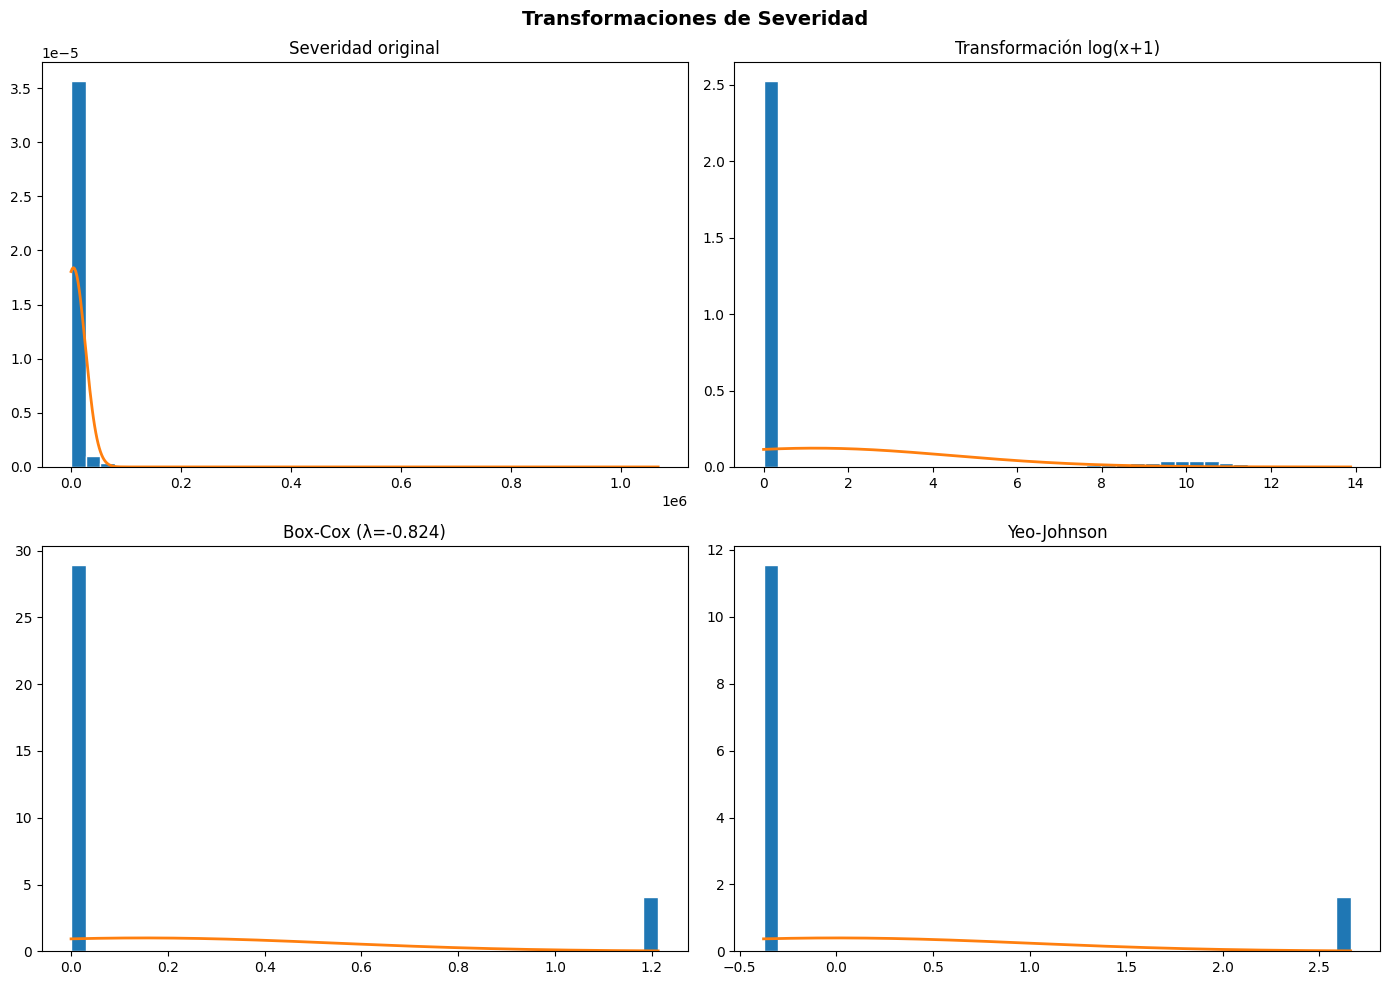


--- Skewness ---
Original    : 14.064
Log(x+1)    : 2.368
Box-Cox     : 2.284
Yeo-Johnson : 2.284


In [69]:
# 5. Transformaciones de severidad
# Box-Cox, Log y Yeo-Johnson

from scipy.stats import (boxcox,norm)

from sklearn.preprocessing import PowerTransformer

import matplotlib.pyplot as plt
import numpy as np
# Variable severidad

sev = df_ramos['monto_pagado'].copy()

# Box-Cox

# Box-Cox NO acepta ceros
# por eso agregamos +1

sev_boxcox, lambda_bc = boxcox(sev + 1)

# Logarítmica

sev_log = np.log1p(sev)

# Yeo-Johnson

pt = PowerTransformer(method='yeo-johnson')

sev_yj = pt.fit_transform(sev.values.reshape(-1,1)).flatten()

# Histogramas comparativos

fig, ax = plt.subplots(2, 2, figsize=(14,10))

# Original

ax[0,0].hist(sev,bins=40,density=True,edgecolor='white')

x = np.linspace(sev.min(),sev.max(),500)

ax[0,0].plot(x,norm.pdf(x,sev.mean(),sev.std()),lw=2)

ax[0,0].set_title('Severidad original')

# Log

ax[0,1].hist(sev_log,bins=40,density=True,edgecolor='white')

x_log = np.linspace(sev_log.min(),sev_log.max(),500)

ax[0,1].plot(x_log,norm.pdf(x_log,sev_log.mean(),sev_log.std()),lw=2)

ax[0,1].set_title('Transformación log(x+1)')

# Box-Cox

ax[1,0].hist(sev_boxcox,bins=40,density=True,edgecolor='white')

x_bc = np.linspace(sev_boxcox.min(),sev_boxcox.max(),500)

ax[1,0].plot(x_bc,norm.pdf(x_bc,sev_boxcox.mean(),sev_boxcox.std()),lw=2)

ax[1,0].set_title(f'Box-Cox (λ={lambda_bc:.3f})')

# Yeo-Johnson

ax[1,1].hist(sev_yj,bins=40,density=True,edgecolor='white')

x_yj = np.linspace(sev_yj.min(),sev_yj.max(),500)

ax[1,1].plot(x_yj,norm.pdf(x_yj,sev_yj.mean(),sev_yj.std()),lw=2)

ax[1,1].set_title('Yeo-Johnson')


plt.suptitle('Transformaciones de Severidad',fontsize=14,fontweight='bold')

plt.tight_layout()
plt.show()

# Comparación de asimetría

print('\n--- Skewness ---')

print(f'Original    : {sev.skew():.3f}')
print(f'Log(x+1)    : {pd.Series(sev_log).skew():.3f}')
print(f'Box-Cox     : {pd.Series(sev_boxcox).skew():.3f}')
print(f'Yeo-Johnson : {pd.Series(sev_yj).skew():.3f}')


#Conclusión:

#La severidad original presenta una distribución
#muy asimétrica hacia la derecha y una cola pesada,
#algo común en variables actuariales.

#La transformación log(x+1) redujo considerablemente
#la asimetría y comprimió los valores extremos.

#Box-Cox también mejoró la aproximación a normalidad,
#aunque requiere valores positivos y por eso fue necesario
#sumar 1 a la severidad.

#Yeo-Johnson fue la transformación más flexible,
#ya que maneja ceros automáticamente y logró
#una distribución más estable.

#En este caso, Yeo-Johnson y log(x+1) fueron
#las transformaciones más adecuadas para preparar
#la severidad para modelos predictivos.

### SE TRABAJO EN EL SIGUIENTE SOLO LAS SEVERIDADES MAYORES A CERO

Total severidades > 0: 3436


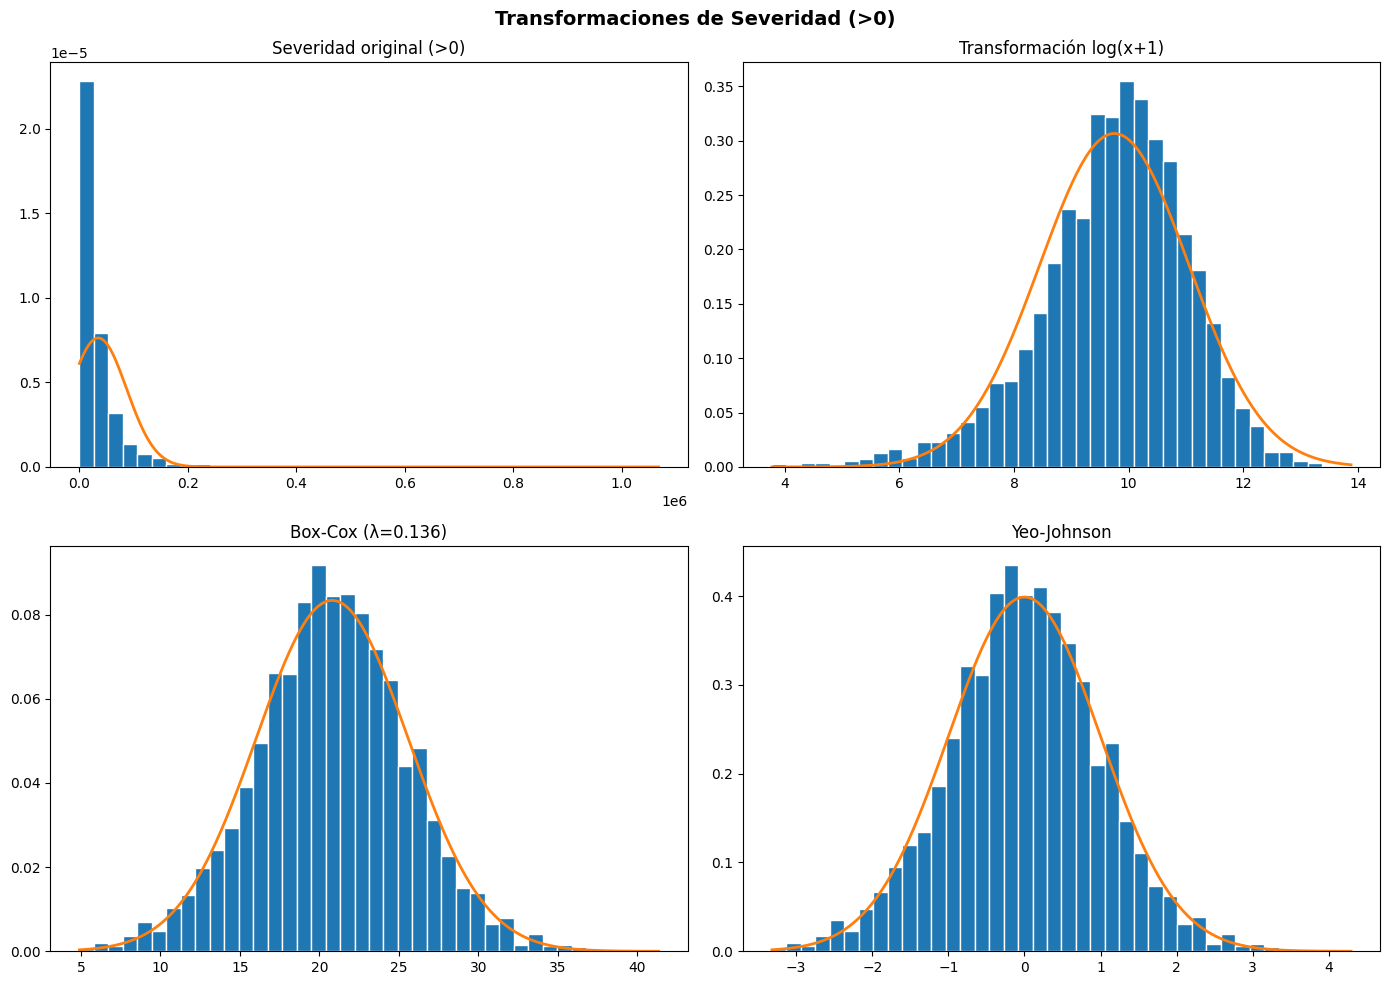


--- Skewness ---
Original    : 6.139
Log(x+1)    : -0.627
Box-Cox     : 0.018
Yeo-Johnson : 0.017


In [70]:
# 5. Transformaciones de severidad
# SOLO severidades mayores a 0

from scipy.stats import (boxcox,norm)

from sklearn.preprocessing import PowerTransformer

# Severidad positiva

# Se consideran únicamente pólizas
# con monto pagado mayor a cero.

sev = (df_ramos[df_ramos['monto_pagado'] > 0]['monto_pagado'].copy())

print(f'Total severidades > 0: {len(sev)}')

# 1. Transformación logarítmica

sev_log = np.log1p(sev)

# 2. Box-Cox

sev_boxcox, lambda_bc = boxcox(sev)

# 3. Yeo-Johnson

pt = PowerTransformer(method='yeo-johnson')

sev_yj = pt.fit_transform(sev.values.reshape(-1,1)).flatten()

# Histogramas comparativos

fig, ax = plt.subplots(2, 2, figsize=(14,10))

# Original

ax[0,0].hist(sev,bins=40,density=True,edgecolor='white')

x = np.linspace(sev.min(),sev.max(),500)

ax[0,0].plot(x,norm.pdf(x,sev.mean(),sev.std()),lw=2)

ax[0,0].set_title('Severidad original (>0)')

# Log(x+1)

ax[0,1].hist(sev_log,bins=40,density=True,edgecolor='white')

x_log = np.linspace(sev_log.min(),sev_log.max(),500)

ax[0,1].plot(x_log,norm.pdf(x_log,sev_log.mean(),sev_log.std()),lw=2)

ax[0,1].set_title('Transformación log(x+1)')

# Box-Cox

ax[1,0].hist(sev_boxcox,bins=40,density=True,edgecolor='white')

x_bc = np.linspace(sev_boxcox.min(),sev_boxcox.max(),500)

ax[1,0].plot(x_bc,norm.pdf(x_bc,sev_boxcox.mean(),sev_boxcox.std()),lw=2)

ax[1,0].set_title(f'Box-Cox (λ={lambda_bc:.3f})')

# Yeo-Johnson

ax[1,1].hist(sev_yj,bins=40,density=True,edgecolor='white')

x_yj = np.linspace(sev_yj.min(),sev_yj.max(),500)

ax[1,1].plot(x_yj,norm.pdf(x_yj,sev_yj.mean(),sev_yj.std()),lw=2)

ax[1,1].set_title('Yeo-Johnson')

plt.suptitle('Transformaciones de Severidad (>0)',fontsize=14,fontweight='bold')

plt.tight_layout()
plt.show()

# Comparación de asimetría

print('\n--- Skewness ---')

print(f'Original    : {sev.skew():.3f}')
print(f'Log(x+1)    : {pd.Series(sev_log).skew():.3f}')
print(f'Box-Cox     : {pd.Series(sev_boxcox).skew():.3f}')
print(f'Yeo-Johnson : {pd.Series(sev_yj).skew():.3f}')


Para el análisis de severidad se utilizaron únicamente
montos mayores a cero, ya que las pólizas sin siniestro
corresponden al componente de frecuencia.

La severidad original presenta una fuerte asimetría
positiva y una cola pesada, típica de variables
actuariales.

Las tres transformaciones lograron reducir
considerablemente la asimetría y aproximar mejor
la distribución a una normal.

La transformación log(x+1) comprimió los valores
extremos y mejoró la estabilidad de la distribución.

Box-Cox presentó una de las mejores aproximaciones
a normalidad, aunque requiere datos positivos.

Yeo-Johnson también tuvo buen desempeño y es más flexible,
ya que puede trabajar con valores cero o negativos.

En este caso, Box-Cox y Yeo-Johnson fueron las
transformaciones más adecuadas para preparar
la severidad para modelos predictivos.


Total severidades > 0: 3436


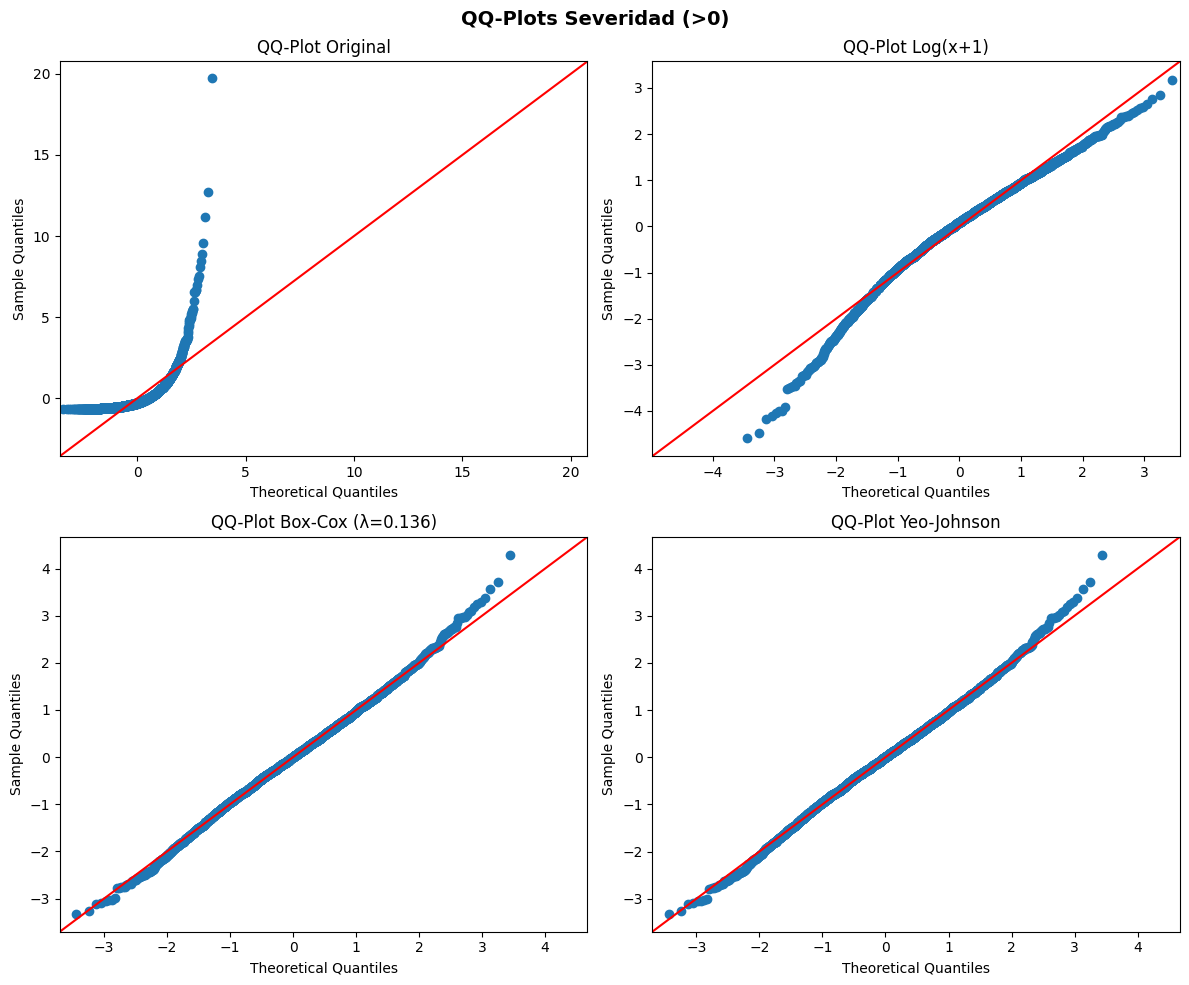


--- Prueba de normalidad (Shapiro-Wilk) ---
Original    -> p-value = 0.000000
Log(x+1)    -> p-value = 0.000000
Box-Cox     -> p-value = 0.000808
Yeo-Johnson -> p-value = 0.000821


In [71]:
# 6. QQ-Plot y prueba de normalidad

from scipy import stats
from sklearn.preprocessing import PowerTransformer
import statsmodels.api as sm

# Severidad positiva (>0)
# Se analizan únicamente pólizas
# con monto pagado mayor a cero.

sev = (df_ramos[df_ramos['monto_pagado'] > 0]['monto_pagado'].copy())

print(f'Total severidades > 0: {len(sev)}')

# Transformaciones
# Logarítmica

sev_log = np.log1p(sev)
# Box-Cox

sev_boxcox, lambda_bc = stats.boxcox(sev)
# Yeo-Johnson

pt = PowerTransformer(method='yeo-johnson')
sev_yj = pt.fit_transform(sev.values.reshape(-1,1)).flatten()

# QQ-Plots

fig, ax = plt.subplots(2, 2, figsize=(12,10))

# Original

sm.qqplot(sev,line='45',fit=True,ax=ax[0,0])

ax[0,0].set_title('QQ-Plot Original')

# Log(x+1)

sm.qqplot(sev_log,line='45',fit=True,ax=ax[0,1])

ax[0,1].set_title('QQ-Plot Log(x+1)')

# Box-Cox

sm.qqplot(sev_boxcox,line='45',fit=True,ax=ax[1,0])

ax[1,0].set_title(f'QQ-Plot Box-Cox (λ={lambda_bc:.3f})')

# Yeo-Johnson

sm.qqplot(sev_yj,line='45',fit=True,ax=ax[1,1])

ax[1,1].set_title('QQ-Plot Yeo-Johnson')

plt.suptitle('QQ-Plots Severidad (>0)',fontsize=14,fontweight='bold')

plt.tight_layout()
plt.show()

# Prueba de normalidad
# Shapiro-Wilk

print('\n--- Prueba de normalidad (Shapiro-Wilk) ---')

# Se toma una muestra para evitar problemas
# con tamaños grandes de datos.

n_sample = min(5000, len(sev))

shapiro_orig = stats.shapiro(sev.sample(n_sample, random_state=1))

shapiro_log = stats.shapiro(pd.Series(sev_log).sample(n_sample, random_state=1))

shapiro_bc = stats.shapiro(pd.Series(sev_boxcox).sample(n_sample, random_state=1))

shapiro_yj = stats.shapiro(pd.Series(sev_yj).sample(n_sample, random_state=1))

print(f'Original    -> p-value = {shapiro_orig.pvalue:.6f}')
print(f'Log(x+1)    -> p-value = {shapiro_log.pvalue:.6f}')
print(f'Box-Cox     -> p-value = {shapiro_bc.pvalue:.6f}')
print(f'Yeo-Johnson -> p-value = {shapiro_yj.pvalue:.6f}')


La severidad original presenta una desviación
muy fuerte de la normalidad, ya que el p-value
es prácticamente cero.

Las transformaciones log(x+1), Box-Cox
y Yeo-Johnson lograron mejorar la distribución,
reduciendo la asimetría y acercando los datos
a una forma más simétrica.

Box-Cox y Yeo-Johnson fueron las transformaciones
con mejor desempeño, porque aumentaron
considerablemente el p-value respecto
a la variable original y a la transformación logarítmica.

Sin embargo, los p-values siguen siendo menores
a 0.05, por lo que estadísticamente aún
se rechaza la hipótesis de normalidad.

Esto es esperado en variables actuariales
de severidad, ya que normalmente presentan
colas pesadas y valores extremos.

Aunque no se obtuvo normalidad perfecta,
las transformaciones sí hicieron la variable
más estable y más adecuada para modelos
predictivos y análisis estadísticos.


In [72]:
# 7. Variables derivadas
# Mayor de 65 años y siniestros altos

# Mayor de 65 años

df_ramos['mayor_65'] = (df_ramos['edad'] > 65)

# Siniestros altos

# Accidentes Personales:
# monto_pagado > 25,000

# GMM:
# monto_pagado > 200,000

df_ramos['siniestro_alto'] = np.where(((df_ramos['ramo'] == 'Accidentes Personales') & (df_ramos['monto_pagado'] > 25000))|((df_ramos['ramo'] == 'GMM') &(df_ramos['monto_pagado'] > 200000)),1,0)

# Resumen general

total_siniestros = ((df_ramos['monto_pagado'] > 0).sum())

total_altos = (df_ramos['siniestro_alto'].sum())

porcentaje_altos = (total_altos / total_siniestros) * 100

# Resumen por ramo

resumen_altos = (df_ramos.groupby('ramo').agg(Total_Siniestros = ('monto_pagado',lambda x: (x > 0).sum()),Siniestros_Altos = ('siniestro_alto','sum'),
Mayores_65 = ('mayor_65','sum')))

resumen_altos['Pct_Siniestros_Altos'] = (resumen_altos['Siniestros_Altos'] / resumen_altos['Total_Siniestros']* 100).round(2)

# Resultados

print('\n--- Resumen de siniestros altos ---')
print(resumen_altos)

print('\n--- Totales generales ---')

print(f'Total siniestros           : {total_siniestros:,}')
print(f'Siniestros altos           : {total_altos:,}')
print(f'% sobre total siniestros   : {porcentaje_altos:.2f}%')



--- Resumen de siniestros altos ---
                       Total_Siniestros  Siniestros_Altos  Mayores_65  \
ramo                                                                    
Accidentes Personales               623               263          37   
Autos                                 0                 0           0   
GMM                                2813                45         161   
Vida                                  0                 0           0   

                       Pct_Siniestros_Altos  
ramo                                         
Accidentes Personales                 42.22  
Autos                                   NaN  
GMM                                    1.60  
Vida                                    NaN  

--- Totales generales ---
Total siniestros           : 3,436
Siniestros altos           : 308
% sobre total siniestros   : 8.96%


C:\Users\angel\AppData\Local\Temp\ipykernel_18616\2103815320.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_altos = (df_ramos.groupby('ramo').agg(Total_Siniestros = ('monto_pagado',lambda x: (x > 0).sum()),Siniestros_Altos = ('siniestro_alto','sum'),



Se identificaron 308 siniestros altos,
los cuales representan aproximadamente
el 8.96% del total de siniestros.

En Accidentes Personales, los siniestros altos
representan una proporción importante del ramo
(42.22%), lo que indica una mayor concentración
de eventos costosos respecto al total de siniestros.

En GMM, aunque el porcentaje de siniestros altos
es menor (1.60%), los montos asociados suelen ser
mucho más elevados, por lo que pueden tener
un impacto financiero significativo.

También se observó presencia de asegurados
mayores de 65 años, especialmente en GMM,
lo que puede relacionarse con una mayor exposición
al riesgo y mayores costos médicos.

Estas variables derivadas permiten segmentar mejor
el riesgo y son útiles para modelos predictivos,
tarificación y análisis actuarial.

In [73]:
# 8. Media del siniestro
# por sexo, año y plan

# Media por sexo

media_sexo = (df_ramos.groupby('sexo',observed=False)['monto_pagado'].mean().round(2).sort_values(ascending=False))

print('\n--- Media del siniestro por sexo ---\n')

display(media_sexo)

# Media por año de inicio de vigencia

media_anio = (df_ramos.groupby('anio_poliza',observed=False)['monto_pagado'].mean().round(2).sort_index())

print('\n--- Media del siniestro por año de inicio ---\n')

display(media_anio)

# Media por plan

media_plan = (df_ramos.groupby('plan',observed=False)['monto_pagado'].mean().round(2).sort_values(ascending=False))

print('\n--- Media del siniestro por plan ---\n')

display(media_plan)



--- Media del siniestro por sexo ---



sexo
F    4551.20
M    4043.76
Name: monto_pagado, dtype: float64


--- Media del siniestro por año de inicio ---



anio_poliza
2019    3935.79
2020    4541.09
2021    4375.73
2022    4564.09
2023    4421.06
2024    3955.30
Name: monto_pagado, dtype: float64


--- Media del siniestro por plan ---



plan
Plus           4469.14
Individual     4367.65
Elite          4256.67
Basico         4249.16
Premium        4227.27
Familiar       4203.66
10 anios           NaN
20 anios           NaN
Amplia             NaN
Amplia Plus        NaN
Permanente         NaN
RC+LT              NaN
Name: monto_pagado, dtype: float64

Análisis general:

A lo largo del ejercicio se observó que
las variables actuariales presentan una
fuerte asimetría y presencia de valores extremos,
especialmente en severidad.

Los histogramas y estadísticas descriptivas
mostraron que la mayoría de los asegurados
tienen siniestros pequeños o incluso cero,
mientras que pocos casos concentran montos muy altos.
Esto es típico en seguros.

Las transformaciones logarítmica, Box-Cox
y Yeo-Johnson ayudaron a reducir la asimetría,
mejorar la estabilidad y acercar las distribuciones
a una forma más adecuada para modelos predictivos.

En las pruebas de normalidad se observó que,
aunque no se alcanzó normalidad perfecta,
las transformaciones sí mejoraron considerablemente
el comportamiento estadístico de la variable.

También se identificó que los siniestros altos
representan un porcentaje pequeño del total,
pero tienen un impacto importante en el costo
y en la siniestralidad del portafolio.

El análisis por sexo, año y plan mostró
que existen diferencias entre segmentos,
lo cual puede utilizarse para tarificación,
segmentación de riesgo y análisis actuarial.

En cuanto al escalamiento, StandardScaler
y RobustScaler fueron útiles para comparar variables
en distintas escalas, mientras que RobustScaler
mostró mayor estabilidad frente a valores extremos.

En general, el ejercicio permitió entender
la importancia de limpiar, transformar
y analizar correctamente los datos antes
de construir modelos predictivos en seguros.